# Project Overview

This project investigates the social and behavioral factors associated with Actual Usage Behavior (AUB) in social commerce among Generation Z university students in Vietnam. Using a secondary dataset of **757 survey responses**, collected between **October 2024 and March 2025** through **voluntary online and offline channels**, the study examines how perceived ease of use, perceived usefulness, familiarity, social participation, trust, and purchase intention relate to actual social commerce engagement. The project aims to identify meaningful user patterns and insights into social commerce adoption among young consumers.

## CBDATSI Phase 1

Phase 1 consists of four sections: (1) dataset description, (2) data cleaning, (3) exploratory data analysis (EDA), and (4) research question formulation.

### [1] Dataset Description

The dataset was collected through an online survey conducted by researchers from the Industrial University of Ho Chi Minh City and Thai Nguyen University of Economics & Business Administration. Participation was voluntary and limited to respondents aged 18–27 years.

Because only Generation Z respondents were included, the findings cannot be generalized to other age groups.

The dataset consists of a single CSV file containing all survey responses, while the questionnaire and codebook provide supporting documentation. Each row represents one respondent, and each column represents either a demographic variable or a survey item measuring a social commerce construct.

In [1]:
# Code explanation: Import the libraries needed to be used.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp

from scipy import stats
from scipy.stats import shapiro
from scipy.stats import kruskal

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

import os
import sys

sys.path.append(os.path.abspath(".."))

# sets the theme of the charts
plt.style.use('seaborn-v0_8-darkgrid')

%matplotlib inline

In [2]:
# Get the folder where this notebook is located
BASE_DIR = os.getcwd()

# Import preprocessing wrapper functions
from preprocessing import (
    load_dataset,
    inspect_dataset,
    validate_columns,
    validate_dtypes,
    drop_columns,
    check_missing_values,
    find_duplicates,
    validate_unique_values,
    compute_composite_score,
)

# Load the dataset from the same folder as the notebook
scommerce_df = pd.read_csv(
    os.path.join(BASE_DIR, "S-COMMERCE_GenZ_UniversityStudent_757_DIB copy.csv")
)

The dataset contains **757 observations** and **31 variables**.

In [3]:
rows, columns = inspect_dataset(scommerce_df)

print(f"Rows (observations): {rows}")
print(f"Columns (variables): {columns}")

Rows (observations): 757
Columns (variables): 31


The variables include demographic information (Gender, Income, Area, and Frequently) and survey items measuring Perceived Usefulness (PU), Perceived Ease of Use (PEU), Familiarity with Social Commerce (FSC), Social Presence (SP), Trust in Platform (TP), Interaction Behavior (IB), and Actual Usage Behavior (AUB).

In [4]:
validate_columns(scommerce_df)

['Gender',
 'Job',
 'Income',
 'Area',
 'Frequently',
 'PU1',
 'PU2',
 'PU3',
 'PU4',
 'PEU1',
 'PEU2',
 'PEU3',
 'PEU4',
 'FSC1',
 'FSC2',
 'FSC3',
 'SP1',
 'SP2',
 'SP3',
 'SP4',
 'TP1',
 'TP2',
 'TP3',
 'IB1',
 'IB2',
 'IB3',
 'IB4',
 'AUB1',
 'AUB2',
 'AUB3',
 'AUB4']

The **Gender** variable has three categories:
- 1 – Male
- 2 – Female
- 3 – Different

In [5]:
scommerce_df['Gender'].value_counts().sort_index()

Gender
1    167
2    588
3      2
Name: count, dtype: int64

The **Income** variable has five categories:

- 1 – Less than 100 USD
- 2 – 100 to <200 USD
- 3 – 200 to <300 USD
- 4 – 300 to <400 USD
- 5 – Above 400 USD

In [6]:
scommerce_df['Income'].value_counts().sort_index()

Income
1    672
2     68
3     12
4      2
5      3
Name: count, dtype: int64

The **Area** variable has three categories:

- 1 – Urban
- 2 – Suburban
- 3 – Rural

In [7]:
scommerce_df['Area'].value_counts().sort_index()

Area
1    461
2     74
3    222
Name: count, dtype: int64

The **Frequently** variable measures social media usage frequency:

- 1 – Daily
- 2 – Weekly
- 3 – Monthly
- 4 – Rarely Used

In [8]:
scommerce_df['Frequently'].value_counts().sort_index()

Frequently
1    725
2     14
3      7
4     11
Name: count, dtype: int64

#### For the following constructs, they use the following scale:
* 1 - Strongly disagree,
* 2 - Disagree
* 3 - Neutral
* 4 - Agree
* 5 - Strongly agree

#### Perceived Usefulness (PU)
Measure the extent to which respondents believe social commerce improves their shopping effectiveness and productivity.
* `PU1`: Using social commerce platforms improves online shopping performance.
* `PU2`: ... increases productivity in finding products.
* `PU3`: ... enhances effectiveness when making online purchases.
* `PU4`: ... are useful for online transactions.

In [9]:
scommerce_df[['PU1','PU2','PU3','PU4']].head()

,PU1,PU2,PU3,PU4
0,4,4,4,4
1,3,3,3,3
2,3,3,3,3
3,5,5,5,5
4,4,4,4,4



#### Perceived Ease of Use (PEU)
Measure how easy respondents find social commerce platforms to use.
* `PEU1`: Interaction with social commerce platforms is clear and understandable.
* `PEU2`: Using social commerce platforms requires little mental effort.
* `PEU3`: It is easy to make social commerce platforms perform desired tasks.



In [10]:
scommerce_df[['PEU1','PEU2','PEU3']].head()

,PEU1,PEU2,PEU3
0,4,4,4
1,3,3,3
2,3,3,3
3,5,5,5
4,4,4,4


However, the CSV file contains a variable `PEU4` that is not documented in the codebook, questionnaire, and its research paper.

In [11]:
scommerce_df['PEU4'].head()

0    4
1    3
2    3
3    5
4    4
Name: PEU4, dtype: int64

Since `PEU4` is not defined in the codebook or questionnaire, its meaning cannot be accurately determined. Therefore, the variable will be removed during data cleaning to maintain data consistency and interpretability throughout the analysis.

#### Familiarity with Social Commerce (FSC)
Measure respondents' familiarity with social commerce platforms.
* `FSC1`: Familiarity gained through personal experience using social commerce platforms.
* `FSC2`: ... reading news, blogs, and related materials.
* `FSC3`: ... communication with others regarding social commerce.
* `FSC4`: ... discussions, reviews, and shared experiences.


In [12]:
scommerce_df[['FSC1','FSC2','FSC3']].head()

,FSC1,FSC2,FSC3
0,4,4,4
1,3,3,3
2,3,3,3
3,5,5,5
4,3,3,3


As seen from the code block above, FSC4 is no longer called as it does not exist in the dataset. Even though it is defined in the codebook, questionnaire, and the study, since it does not appear in the CSV file of the dataset, calling it will only cause errors. Therefore, it is disregarded. Further explanation will be provided in the Data Cleaning section.


#### Social Presence (SP)
Measure the degree of social interaction experienced through social commerce platforms.
* `SP1`: Frequency of attending online group meetings or events through social commerce platforms.
* `SP2`: ... socializing with friends through social commerce platforms.
* `SP3`: ... socializing with relatives through social commerce platforms.
* `SP4`: General level of social interaction and engagement on social commerce platforms.

In [13]:
scommerce_df[['SP1','SP2','SP3', 'SP4']].head()

,SP1,SP2,SP3,SP4
0,4,4,4,4
1,3,3,3,3
2,3,3,3,3
3,5,5,5,5
4,2,3,3,3



#### Trust in Platform (TP)
Measure respondents' trust in social commerce platforms.
* `TP1`: Social commerce platforms are competent and effective.
* `TP2`: ... act in users' best interests.
* `TP3`: ... can be trusted consistently.


In [14]:
scommerce_df[['TP1','TP2','TP3']].head()

,TP1,TP2,TP3
0,4,4,4
1,3,3,3
2,3,3,3
3,5,5,5
4,3,3,3



#### Interaction Behavior (IB)
Measure respondents' willingness to interact and share information with others through social commerce platforms.
* `IB1`: Willingness to provide information to vendors.
* `IB2`: ... share shopping experiences and suggestions with friends.
* `IB3`: ... purchase products recommended by friends.
* `IB4`: ... consider friends' shopping experiences when making purchases.

In [15]:
scommerce_df[['IB1','IB2','IB3', 'IB4']].head()

,IB1,IB2,IB3,IB4
0,3,3,3,3
1,3,3,3,3
2,3,3,3,3
3,5,5,5,5
4,4,4,3,4


#### Actual Usage Behavior (AUB)
Measure respondents' actual usage of social commerce platforms.
* `AUB1`: Using social commerce platforms is enjoyable.
* `AUB2`: Uses social commerce platforms for safe online shopping.
* `AUB3`: Spends significant time on social commerce platforms.
* `AUB4`: Regularly uses social commerce platforms.

### [2] Data Cleaning

Before analysis, the dataset was inspected for data quality issues that could affect the validity and reliability of the results. The variables were checked for missing values, duplicate records, incorrect data types, inconsistent formatting, and invalid values. Appropriate preprocessing was applied where necessary.

#### Variable Verification

Before cleaning, the dataset variables were verified against the questionnaire and accompanying study to ensure that all expected variables were correctly loaded and matched the constructs defined by the authors.

In [16]:
scommerce_df.columns

Index(['Gender', 'Job', 'Income', 'Area', 'Frequently', 'PU1', 'PU2', 'PU3',
       'PU4', 'PEU1', 'PEU2', 'PEU3', 'PEU4', 'FSC1', 'FSC2', 'FSC3', 'SP1',
       'SP2', 'SP3', 'SP4', 'TP1', 'TP2', 'TP3', 'IB1', 'IB2', 'IB3', 'IB4',
       'AUB1', 'AUB2', 'AUB3', 'AUB4'],
      dtype='str')

Since `PEU4` is not documented in the codebook, questionnaire, or associated research paper, its meaning cannot be verified. Therefore, the variable is removed to avoid ambiguity in the analysis.

In [17]:
# Remove the PEU4 column
scommerce_df = drop_columns(
    scommerce_df,
    ["PEU4"]
)

# Verify removal
print(inspect_dataset(scommerce_df))
scommerce_df.head()

(757, 30)


,Gender,Job,Income,Area,Frequently,PU1,PU2,PU3,PU4,PEU1,...,TP2,TP3,IB1,IB2,IB3,IB4,AUB1,AUB2,AUB3,AUB4
0,2,1,1,1,1,4,4,4,4,4,...,4,4,3,3,3,3,4,4,4,4
1,2,1,1,1,1,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,4,2,4
3,1,1,1,3,1,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
4,2,1,1,3,1,4,4,4,4,4,...,3,3,4,4,3,4,3,3,3,3


The dataset dimensions and first few rows are displayed to confirm that the `PEU4` column was successfully removed.

In [18]:
scommerce_df.columns

Index(['Gender', 'Job', 'Income', 'Area', 'Frequently', 'PU1', 'PU2', 'PU3',
       'PU4', 'PEU1', 'PEU2', 'PEU3', 'FSC1', 'FSC2', 'FSC3', 'SP1', 'SP2',
       'SP3', 'SP4', 'TP1', 'TP2', 'TP3', 'IB1', 'IB2', 'IB3', 'IB4', 'AUB1',
       'AUB2', 'AUB3', 'AUB4'],
      dtype='str')

All expected variables were successfully loaded from the dataset. An additional variable, `Job`, is present but is not documented in the questionnaire, codebook, or accompanying research paper. Its contents are inspected to determine whether it should be retained.

In [19]:
# Check the unique values in the Job column
print("Unique values in Job:", scommerce_df['Job'].unique())
print("Number of unique values:", scommerce_df['Job'].nunique())

Unique values in Job: [1]
Number of unique values: 1


Inspection showed that all 757 values of `Job` were identical. Since the variable has no variation and is not documented in the questionnaire or research paper, it was removed from the dataset.

In [20]:
# Remove the Job column
scommerce_df = drop_columns(
    scommerce_df,
    ["Job"]
)

# Verify removal
print(inspect_dataset(scommerce_df))
scommerce_df.head()

(757, 29)


,Gender,Income,Area,Frequently,PU1,PU2,PU3,PU4,PEU1,PEU2,...,TP2,TP3,IB1,IB2,IB3,IB4,AUB1,AUB2,AUB3,AUB4
0,2,1,1,1,4,4,4,4,4,4,...,4,4,3,3,3,3,4,4,4,4
1,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,2,1,1,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,4,2,4
3,1,1,3,1,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
4,2,1,3,1,4,4,4,4,4,4,...,3,3,4,4,3,4,3,3,3,3


The cleaned dataset now contains 30 documented variables.

### Missing Values

The dataset was checked for missing values, as incomplete records could affect subsequent analyses.

In [21]:
check_missing_values(scommerce_df)

Gender        0
Income        0
Area          0
Frequently    0
PU1           0
PU2           0
PU3           0
PU4           0
PEU1          0
PEU2          0
PEU3          0
FSC1          0
FSC2          0
FSC3          0
SP1           0
SP2           0
SP3           0
SP4           0
TP1           0
TP2           0
TP3           0
IB1           0
IB2           0
IB3           0
IB4           0
AUB1          0
AUB2          0
AUB3          0
AUB4          0
dtype: int64

No missing values were found in the dataset; therefore, all observations were retained. This is consistent with the dataset documentation, which states that incomplete responses and low-quality submissions were removed during the authors' data screening process.

### Duplicate Values

The dataset was checked for duplicate records to ensure that each observation was unique before analysis.

In [22]:
# Identify duplicate rows
duplicate_rows = find_duplicates(scommerce_df)

# View duplicate rows
duplicate_rows

,Gender,Income,Area,Frequently,PU1,PU2,PU3,PU4,PEU1,PEU2,...,TP2,TP3,IB1,IB2,IB3,IB4,AUB1,AUB2,AUB3,AUB4
12,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
14,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
20,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
21,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
24,2,1,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,2,1,1,1,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
718,2,1,1,1,4,4,4,4,4,4,...,3,3,4,4,4,4,4,4,4,4
719,2,1,1,1,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
724,2,2,1,1,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4


Although duplicate records were identified, the dataset contains no unique respondent identifier. Different participants may therefore have identical responses. Since the dataset documentation states that the authors had already screened the data before publication, these records were retained.

### Data Type Checks

The data types of each variable were verified to ensure compatibility with subsequent preprocessing and analysis.

In [23]:
validate_dtypes(scommerce_df)

Gender        int64
Income        int64
Area          int64
Frequently    int64
PU1           int64
PU2           int64
PU3           int64
PU4           int64
PEU1          int64
PEU2          int64
PEU3          int64
FSC1          int64
FSC2          int64
FSC3          int64
SP1           int64
SP2           int64
SP3           int64
SP4           int64
TP1           int64
TP2           int64
TP3           int64
IB1           int64
IB2           int64
IB3           int64
IB4           int64
AUB1          int64
AUB2          int64
AUB3          int64
AUB4          int64
dtype: object

All variables were loaded using the expected numerical data types. The demographic variables (`Gender`, `Income`, `Area`, and `Frequently`) were already numerically encoded by the dataset authors, so no data type conversion was required.

### Formatting and Range Check

After verifying the data types, the recorded values were checked to ensure they matched the expected categories and response scales. Demographic variables were compared against the dataset documentation, while survey items were verified to contain only valid Likert scale responses (1–5). This confirms that no invalid or improperly encoded values are present.

In [24]:
unique_summary = validate_unique_values(scommerce_df)

unique_summary

,Variable,Unique Count,Unique Values
0,Gender,3,"[1, 2, 3]"
1,Income,5,"[1, 2, 3, 4, 5]"
2,Area,3,"[1, 2, 3]"
3,Frequently,4,"[1, 2, 3, 4]"
4,PU1,5,"[1, 2, 3, 4, 5]"
5,PU2,5,"[1, 2, 3, 4, 5]"
6,PU3,5,"[1, 2, 3, 4, 5]"
7,PU4,5,"[1, 2, 3, 4, 5]"
8,PEU1,5,"[1, 2, 3, 4, 5]"
9,PEU2,5,"[1, 2, 3, 4, 5]"


The results confirm that all variables are within their expected format and range. No invalid values were identified; therefore, no observations were removed.

### Composite Score Creation

Composite scores were created by averaging the survey items corresponding to each construct, producing a single representative score for analysis. This approach is consistent with the methodology used by the dataset authors.

In [25]:
# Perceived Usefulness
scommerce_df = compute_composite_score(
    scommerce_df,
    ['PU1', 'PU2', 'PU3', 'PU4'],
    'PU'
)

# Perceived Ease of Use
scommerce_df = compute_composite_score(
    scommerce_df,
    ['PEU1', 'PEU2', 'PEU3'],
    'PEU'
)

# Familiarity with Social Commerce
scommerce_df = compute_composite_score(
    scommerce_df,
    ['FSC1', 'FSC2', 'FSC3'],
    'FSC'
)

# Social Presence
scommerce_df = compute_composite_score(
    scommerce_df,
    ['SP1', 'SP2', 'SP3', 'SP4'],
    'SP'
)

# Trust in Platform
scommerce_df = compute_composite_score(
    scommerce_df,
    ['TP1', 'TP2', 'TP3'],
    'TP'
)

# Interaction Behavior
scommerce_df = compute_composite_score(
    scommerce_df,
    ['IB1', 'IB2', 'IB3', 'IB4'],
    'IB'
)

# Actual Usage Behavior
scommerce_df = compute_composite_score(
    scommerce_df,
    ['AUB1', 'AUB2', 'AUB3', 'AUB4'],
    'AUB'
)

The PU questionnaire items are averaged row-wise (`axis=1`) to create one composite score per respondent, which is stored in a new `PU` column. The same procedure is applied to the remaining constructs (PEU, FSC, SP, TP, IB, and AUB).

In [26]:
scommerce_df[['PU', 'PEU', 'FSC', 'SP', 'TP', 'IB', 'AUB']].head()

,PU,PEU,FSC,SP,TP,IB,AUB
0,4.0,4.0,4.0,4.00,4.0,3.00,4.00
1,3.0,3.0,3.0,3.00,3.0,3.00,3.00
2,3.0,3.0,3.0,3.00,3.0,3.00,3.25
3,5.0,5.0,5.0,5.00,5.0,5.00,5.00
4,4.0,4.0,3.0,2.75,3.0,3.75,3.00


The first five rows of the composite score variables are displayed to verify the computed scores.

Following the methodology of the original research paper, questionnaire items were averaged to create composite scores for each construct. These representative variables (`PU`, `PEU`, `FSC`, `SP`, `TP`, `IB`, and `AUB`) simplify subsequent analyses and are used throughout the remainder of the notebook.

### [3] Exploratory Data Analysis

#### **1. What does the demographic composition of the sample look like, and is it skewed in any way?**

The demographic variables (`Gender`, `Income`, `Area`, and `Frequently`) are analyzed to describe the sample and identify any overrepresented groups that may influence the interpretation of subsequent analyses.

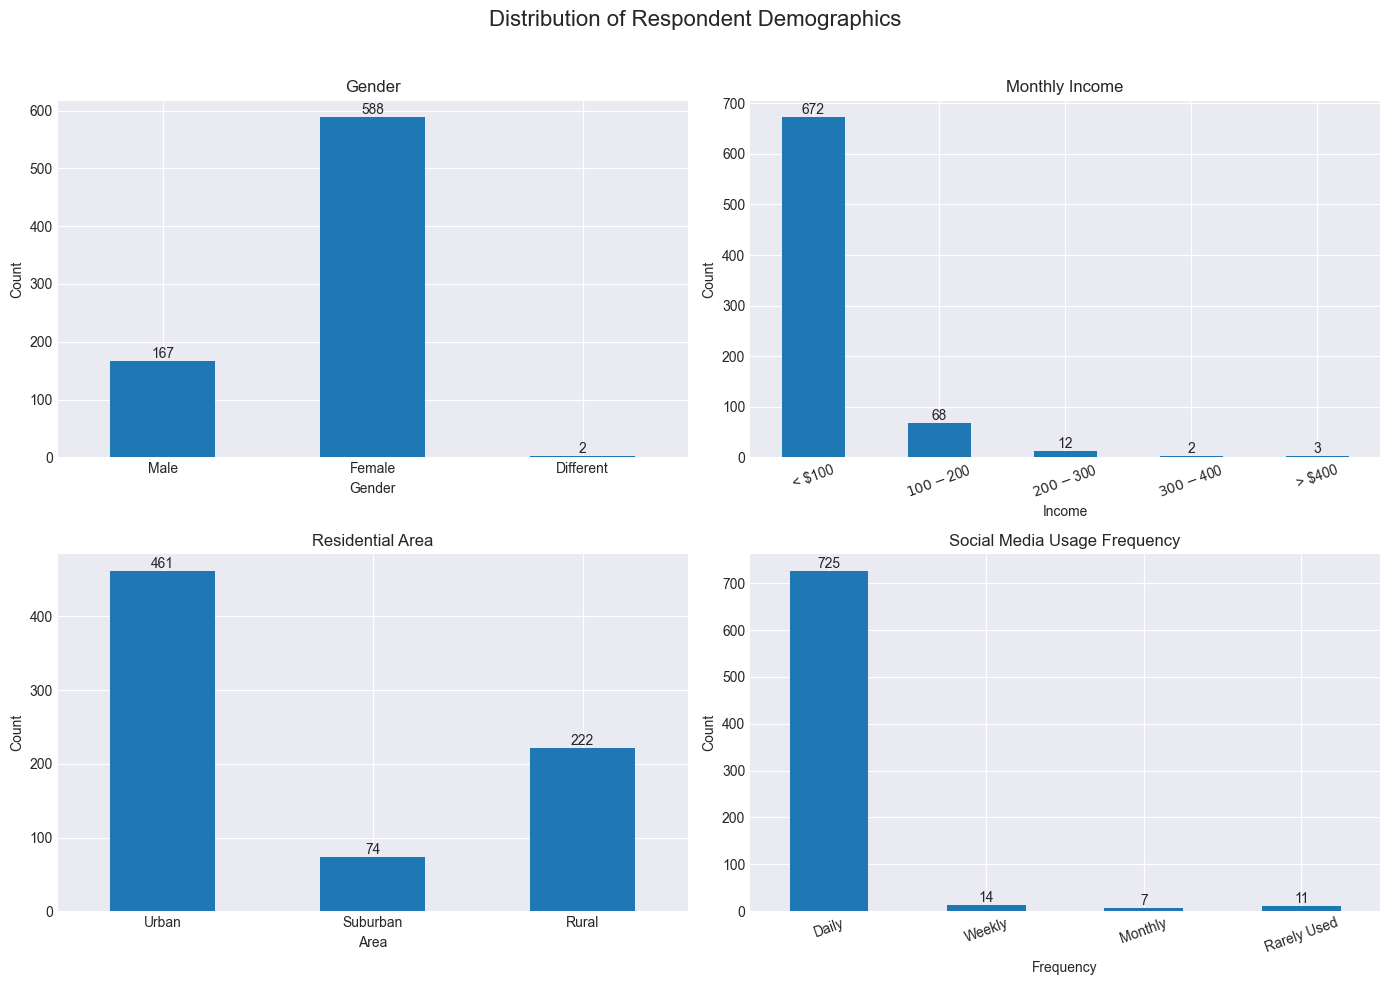

In [27]:

# Count observations
gender_counts = scommerce_df["Gender"].value_counts().sort_index()
income_counts = scommerce_df["Income"].value_counts().sort_index()
area_counts = scommerce_df["Area"].value_counts().sort_index()
freq_counts = scommerce_df["Frequently"].value_counts().sort_index()

# Replace numeric codes
gender_counts.index = gender_counts.index.map({
    1: "Male",
    2: "Female",
    3: "Different"
})

income_counts.index = income_counts.index.map({
    1: "< $100",
    2: "$100-$200",
    3: "$200-$300",
    4: "$300-$400",
    5: "> $400"
})

area_counts.index = area_counts.index.map({
    1: "Urban",
    2: "Suburban",
    3: "Rural"
})

freq_counts.index = freq_counts.index.map({
    1: "Daily",
    2: "Weekly",
    3: "Monthly",
    4: "Rarely Used"
})

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
ax = axes[0, 0]
gender_counts.plot(kind="bar", ax=ax)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)

# Income
ax = axes[0, 1]
income_counts.plot(kind="bar", ax=ax)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Monthly Income")
ax.set_xlabel("Income")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)

# Residential Area
ax = axes[1, 0]
area_counts.plot(kind="bar", ax=ax)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Residential Area")
ax.set_xlabel("Area")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)

# Social Media Usage Frequency
ax = axes[1, 1]
freq_counts.plot(kind="bar", ax=ax)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Social Media Usage Frequency")
ax.set_xlabel("Frequency")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)

# Overall formatting
fig.suptitle("Distribution of Respondent Demographics", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

The sample is predominantly **female**, has **income below $100**, resides mainly in **urban areas**, and reports **daily social media usage**. Overall, the respondents represent digitally active university students, providing an appropriate sample for examining social commerce behavior.

#### Summary

The sample primarily consists of female university students with low income, most of whom live in urban areas and use social media daily. These characteristics are consistent with the study's target population and provide appropriate context for interpreting the subsequent analyses of social commerce behavior.

#### **2. How are each of the constructs (PU, PEU, FSC, SP, TP, IB, AUB) distributed among respondents?**

Descriptive statistics and histograms are used to examine the distribution of the composite scores, allowing the central tendency, variability, and overall response patterns of each construct to be assessed.

In [28]:
# Summary statistics for the composite constructs
constructs = ['PU', 'PEU', 'FSC', 'SP', 'TP', 'IB', 'AUB']

# Generate descriptive statistics
scommerce_df[constructs].describe()

,PU,PEU,FSC,SP,TP,IB,AUB
count,757.000000,757.000000,757.000000,757.000000,757.000000,757.000000,757.000000
mean,3.773448,3.700132,3.730956,3.601717,3.557023,3.606011,3.676684
std,0.702081,0.710670,0.749862,0.701395,0.730930,0.703760,0.707042
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.250000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,4.000000,4.000000,4.000000,3.750000,3.666667,3.750000,3.750000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Across all constructs, mean scores ranged from **3.56** to **3.77**, indicating generally positive responses.

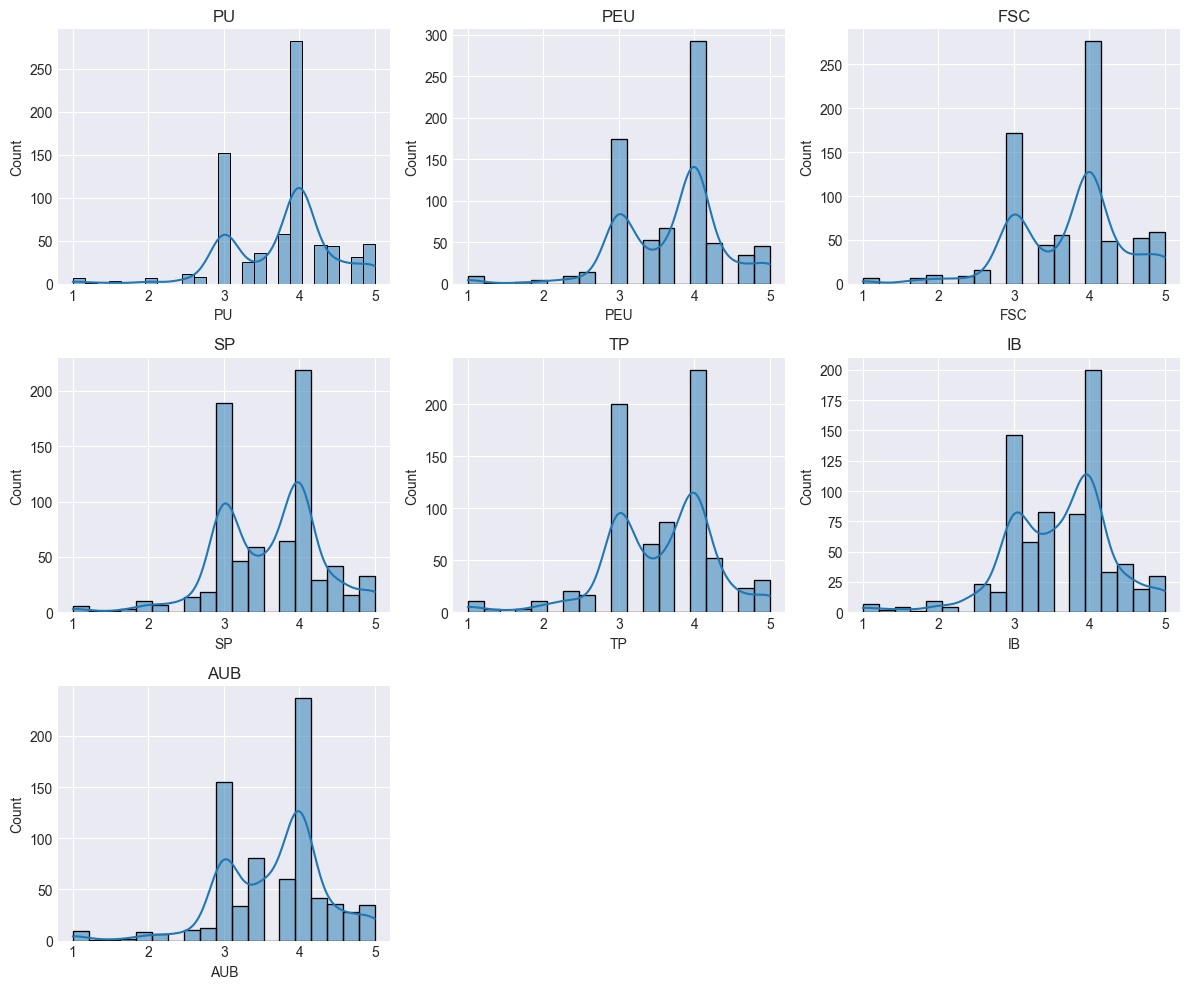

In [29]:
# Plot distributions of the composite constructs
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, construct in enumerate(constructs):
    sns.histplot(
        scommerce_df[construct],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(construct)

# Remove unused subplots
for j in range(len(constructs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The histograms show similar distributions across all constructs, with responses concentrated around scores of 3 and 4. The larger peak near 4 indicates generally positive responses, while the smaller peak near 3 reflects more neutral evaluations. Overall, the distributions exhibit slight bimodal characteristics rather than perfect normality.

#### **3. How are the behavioral/perception constructs (PU, PEU, FSC, SP, TP, IB) related to each other?**

Pearson correlation analysis was performed on the composite construct scores (`PU`, `PEU`, `FSC`, `SP`, `TP`, `IB`, and `AUB`) to examine the relationships among the behavioral and perception constructs and their association with actual social commerce usage.

Construct Score Computation

The following code computes the average score for each construct:

In [30]:
scommerce_df['PU'] = scommerce_df[['PU1','PU2','PU3','PU4']].mean(axis=1)
scommerce_df['PEU'] = scommerce_df[['PEU1','PEU2','PEU3']].mean(axis=1)
scommerce_df['FSC'] = scommerce_df[['FSC1','FSC2','FSC3']].mean(axis=1)
scommerce_df['SP'] = scommerce_df[['SP1','SP2','SP3','SP4']].mean(axis=1)
scommerce_df['TP'] = scommerce_df[['TP1','TP2','TP3']].mean(axis=1)
scommerce_df['IB'] = scommerce_df[['IB1','IB2','IB3','IB4']].mean(axis=1)
scommerce_df['AUB'] = scommerce_df[['AUB1','AUB2','AUB3','AUB4']].mean(axis=1)

#### Correlation Matrix

The table below presents the Pearson correlation coefficients between the composite constructs.

In [31]:
constructs = scommerce_df[['PU','PEU','FSC','SP','TP','IB', 'AUB']]

corr_matrix = constructs.corr(method='pearson')

print(corr_matrix)

           PU       PEU       FSC        SP        TP        IB       AUB
PU   1.000000  0.788226  0.804070  0.718057  0.676910  0.655539  0.771895
PEU  0.788226  1.000000  0.776458  0.717394  0.674808  0.691334  0.785858
FSC  0.804070  0.776458  1.000000  0.766774  0.710337  0.657147  0.744687
SP   0.718057  0.717394  0.766774  1.000000  0.734756  0.644206  0.691883
TP   0.676910  0.674808  0.710337  0.734756  1.000000  0.663131  0.662269
IB   0.655539  0.691334  0.657147  0.644206  0.663131  1.000000  0.683213
AUB  0.771895  0.785858  0.744687  0.691883  0.662269  0.683213  1.000000


Correlation Heatmap

To visualize these relationships more clearly, a heatmap was generated.

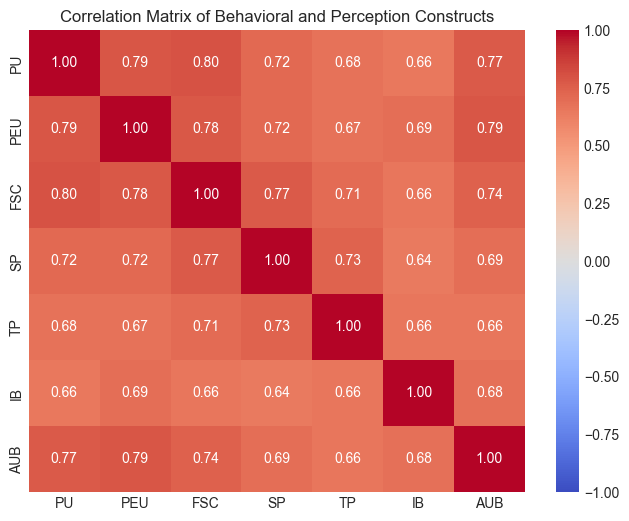

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(
	corr_matrix,
	annot=True,
	cmap='coolwarm',
	vmin=-1,
	vmax=1,
	fmt='.2f'
)

plt.title('Correlation Matrix of Behavioral and Perception Constructs')
plt.show()

#### Interpretation

All constructs are positively correlated (**r** = **0.63–0.80**), indicating that higher scores in one construct are generally associated with higher scores in the others. The strongest relationships were **PU–FSC** (*r* = 0.80) and **PU–PEU** (*r* = 0.79), while **SP–IB** showed the weakest (*r* = 0.63). Overall, the constructs are closely interconnected.

#### **4. Which of these constructs show the strongest relationship with AUB specifically?**

Pearson correlation analysis was used to examine the relationship between each behavioral and perception construct and Actual Usage Behavior (`AUB`), allowing the strongest associations with social commerce usage to be identified.

All behavioral and perception constructs are positively correlated with **Actual Usage Behavior (AUB)** (**r** = **0.66–0.79**). **PEU** shows the strongest relationship (*r* = 0.79), followed by **PU** (*r* = 0.77) and **FSC** (*r* = 0.74), while **TP** shows the weakest (*r* = 0.66). Overall, the positive correlations support the inclusion of all six constructs as predictor variables in the subsequent machine learning models.

#### **5. How does Actual Usage Behavior vary across demographic groups?**

Actual Usage Behavior (AUB) is compared across the demographic groups (`Gender`, `Income`, `Area`, and `Frequently`) to identify potential differences.

#### A. AUB Across Genders

Actual Usage Behavior (AUB) is compared between male and female respondents using descriptive statistics and boxplots. The **"Different"** category was excluded due to its small sample size (**n = 2**).

In [33]:
gender_df = scommerce_df[scommerce_df['Gender'] != 3]

gender_summary = (
    gender_df
    .groupby('Gender')['AUB']
    .agg(['count', 'mean', 'median', 'std'])
)

gender_summary.index = gender_summary.index.map({
    1: 'Male',
    2: 'Female'
})

gender_summary

,count,mean,median,std
Gender,,,,
Male,167,3.658683,3.75,0.789311
Female,588,3.686650,4.00,0.674685


To better visualize the distribution of Actual Usage Behavior (AUB) across gender groups, a box plot is presented below.

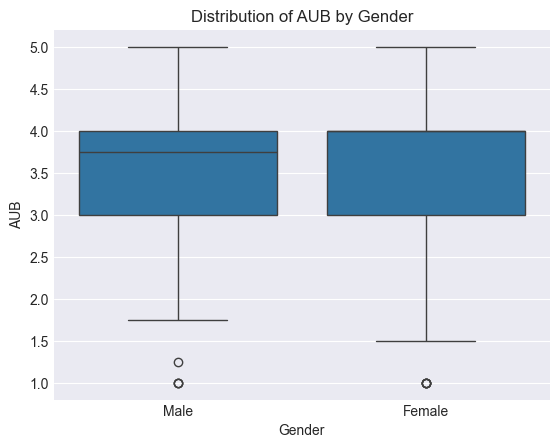

In [34]:
sns.boxplot(
    data=gender_df,
    x='Gender',
    y='AUB'
)

plt.xticks([0, 1], ['Male', 'Female'])

plt.title('Distribution of AUB by Gender')
plt.xlabel('Gender')
plt.ylabel('AUB')

plt.show()

Male and female respondents exhibit very similar AUB distributions. Although females reported slightly higher mean (M = 3.69, SD = 0.67) and median (4.00) scores than males (M = 3.66, SD = 0.79; Median = 3.75), the differences are minimal.

Although descriptive statistics suggest only minor gender differences in AUB, an independent samples *t*-test was conducted to determine whether the mean AUB scores differ significantly. A significance level of α = 0.05 was used.

- $H_0: \mu_{Male} = \mu_{Female}$
- $H_1: \mu_{Male} \ne \mu_{Female}$

In [35]:
male = gender_df[gender_df['Gender'] == 1]['AUB']
female = gender_df[gender_df['Gender'] == 2]['AUB']

t_stat, p_value = stats.ttest_ind(
    male,
    female,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -0.4167
P-value: 0.6773


The independent samples *t*-test found no significant difference in Actual Usage Behavior (AUB) between male and female respondents (*t* = -0.417, *p* = 0.677). Therefore, the null hypothesis was not rejected.

#### B. AUB Across Income

Actual Usage Behavior (AUB) is compared across income groups. The distribution of respondents is first examined to identify any substantial imbalance in group sizes that may affect interpretation.

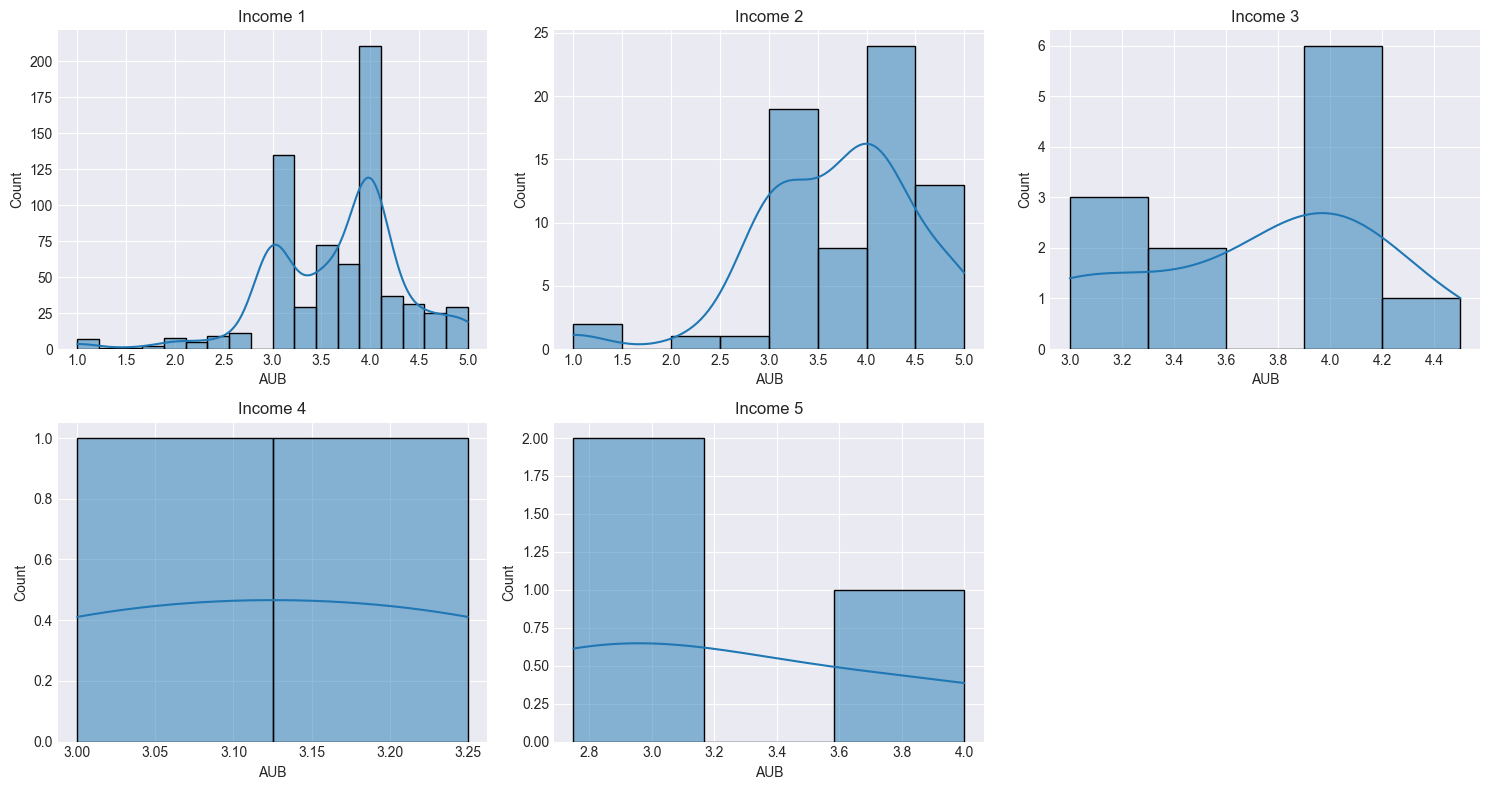

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()

for i, income in enumerate(sorted(scommerce_df['Income'].unique())):
    sns.histplot(
        scommerce_df[scommerce_df['Income'] == income]['AUB'],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Income {income}')
    axes[i].set_xlabel('AUB')
    axes[i].set_ylabel('Count')

# Remove unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

The income groups are highly imbalanced, with very few respondents in the highest income categories. Combined with the non-normal distributions, particularly for the smallest groups, this violates the assumptions of one-way ANOVA. Therefore, only descriptive comparisons are presented.

#### C. AUB Across Area

Actual Usage Behavior (AUB) is compared across urban, suburban, and rural respondents to identify potential differences.

In [37]:
area_summary = (
    scommerce_df
    .groupby('Area')['AUB']
    .agg(['count', 'mean', 'median', 'std'])
)

area_summary.index = area_summary.index.map({
    1: 'Urban',
    2: 'Suburban',
    3: 'Rural'
})

area_summary

,count,mean,median,std
Area,,,,
Urban,461,3.711497,4.00,0.700356
Suburban,74,3.641892,3.75,0.691288
Rural,222,3.615991,3.75,0.724337


The table and boxplot summarize the distribution of AUB across residential areas.

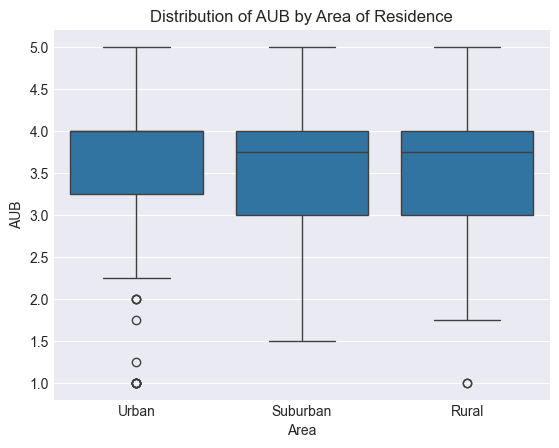

In [38]:
sns.boxplot(
    data=scommerce_df,
    x='Area',
    y='AUB'
)

plt.xticks(
    [0, 1, 2],
    ['Urban', 'Suburban', 'Rural']
)

plt.title('Distribution of AUB by Area of Residence')
plt.xlabel('Area')
plt.ylabel('AUB')

plt.show()

Urban respondents reported the highest AUB (M = 3.71, SD = 0.70), while suburban (M = 3.64, SD = 0.69) and rural respondents (M = 3.62, SD = 0.72) showed similar values. Median AUB was 4.00 for urban respondents and 3.75 for the other two groups.

Although descriptive statistics suggest only minor differences in AUB across residential areas, a one-way ANOVA was conducted to test whether the mean AUB scores differ significantly (α = 0.05).

- $H_0: \mu_{Urban} = \mu_{Suburban} = \mu_{Rural}$
- $H_1:$ At least one group mean differs.

In [39]:
urban = scommerce_df[scommerce_df['Area'] == 1]['AUB']
suburban = scommerce_df[scommerce_df['Area'] == 2]['AUB']
rural = scommerce_df[scommerce_df['Area'] == 3]['AUB']

f_stat, p_value = stats.f_oneway(
    urban,
    suburban,
    rural
)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 1.4681
P-value: 0.2310


The one-way ANOVA found no significant differences in AUB across residential areas (*F* = 1.4681, *p* = 0.2310). Therefore, the null hypothesis was not rejected.

#### D. AUB Across Frequency

Actual Usage Behavior (AUB) is compared across social media usage frequency groups to identify potential differences.

In [40]:
frequency_summary = (
    scommerce_df
    .groupby('Frequently')['AUB']
    .agg(['count', 'mean', 'median', 'std'])
)

frequency_summary.index = frequency_summary.index.map({
    1: 'Daily',
    2: 'Weekly',
    3: 'Monthly',
    4: 'Rarely'
})

frequency_summary

,count,mean,median,std
Frequently,,,,
Daily,725,3.681724,4.00,0.701587
Weekly,14,3.678571,4.00,0.895655
Monthly,7,3.750000,3.75,0.677003
Rarely,11,3.295455,3.25,0.820200


To better understand the distribution, a graph showing the distribution is shown below.

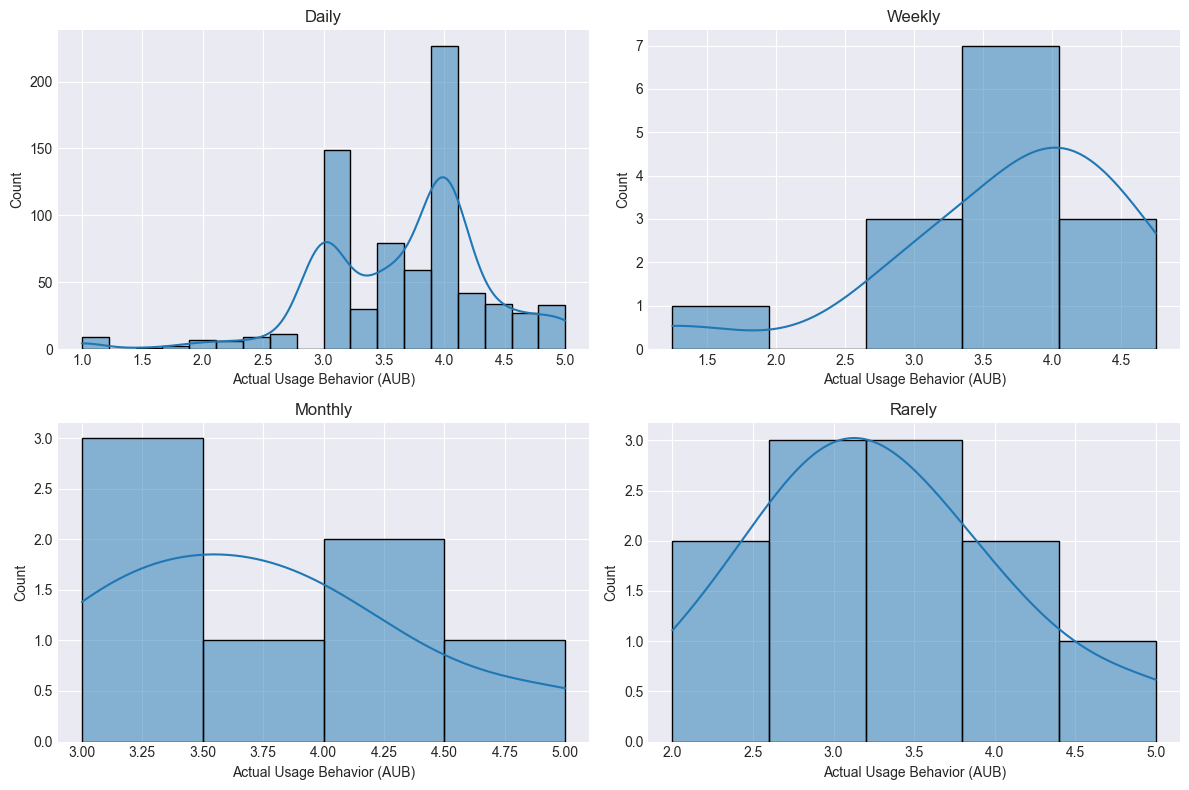

In [41]:
# Label mapping
frequency_labels = {
    1: 'Daily',
    2: 'Weekly',
    3: 'Monthly',
    4: 'Rarely'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, freq in enumerate(sorted(scommerce_df['Frequently'].unique())):
    sns.histplot(
        scommerce_df[scommerce_df['Frequently'] == freq]['AUB'],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(frequency_labels[freq])
    axes[i].set_xlabel('Actual Usage Behavior (AUB)')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

The frequency groups are highly imbalanced, with very few respondents in the weekly, monthly, and rarely used categories. Therefore, the analysis is limited to descriptive comparisons of AUB across frequency groups.

### [4] Research Question

#### **How does actual usage behavior differ among clusters of Generation Z university students formed based on their perceived usefulness, perceived ease of use, familiarity with social commerce, social presence, trust in platform, and interaction behavior?**

The exploratory data analysis showed that the behavioral and perception constructs are moderately to strongly correlated, suggesting that respondents may form distinct user segments.

This study investigates whether clustering respondents based on these constructs reveals differences in Actual Usage Behavior (AUB). The results provide insights into user segments that may support targeted marketing, personalized platform improvements, and future social commerce research.

## **CBDATSI Phase 2**

The first phase of the case study involves four sections – (1) Data Modelling, (2) Statistical Inference, (3) Insights and Conclusions.

### [1] Data Modelling

#### **Feature Selection**
The six behavioral constructs were used as features for clustering because they represent the respondents' perceptions and behaviors associated with social commerce.



In [42]:
features = [
    "PU",
    "PEU",
    "FSC",
    "SP",
    "TP",
    "IB"
]

X = scommerce_df[features]

 #### **Feature Standardization**
 The selected constructs were standardized to ensure equal contribution to the distance calculations used by K-Means.

In [43]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### **Variance Inflation Factor (VIF)**
VIF was computed to assess multicollinearity before clustering, with VIF > 5 indicating potentially problematic multicollinearity.

In [44]:
vif_data = pd.DataFrame()
vif_data["Construct"] = features
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

print(vif_data)

  Construct       VIF
0        PU  3.654939
1       PEU  3.515319
2       FSC  3.988501
3        SP  3.150629
4        TP  2.709242
5        IB  2.301402


VIF values ranged from 2.30 to 3.99, indicating no severe multicollinearity. Therefore, all constructs were retained.

#### **Clustering Algorithm**
K-Means was selected because of its computational efficiency and scalability for clustering the dataset.

#### **Selecting Optimal Number of k**
The optimal number of clusters was determined using the Elbow Method and Silhouette Analysis. The optimal value of k was selected by considering the results of both methods.

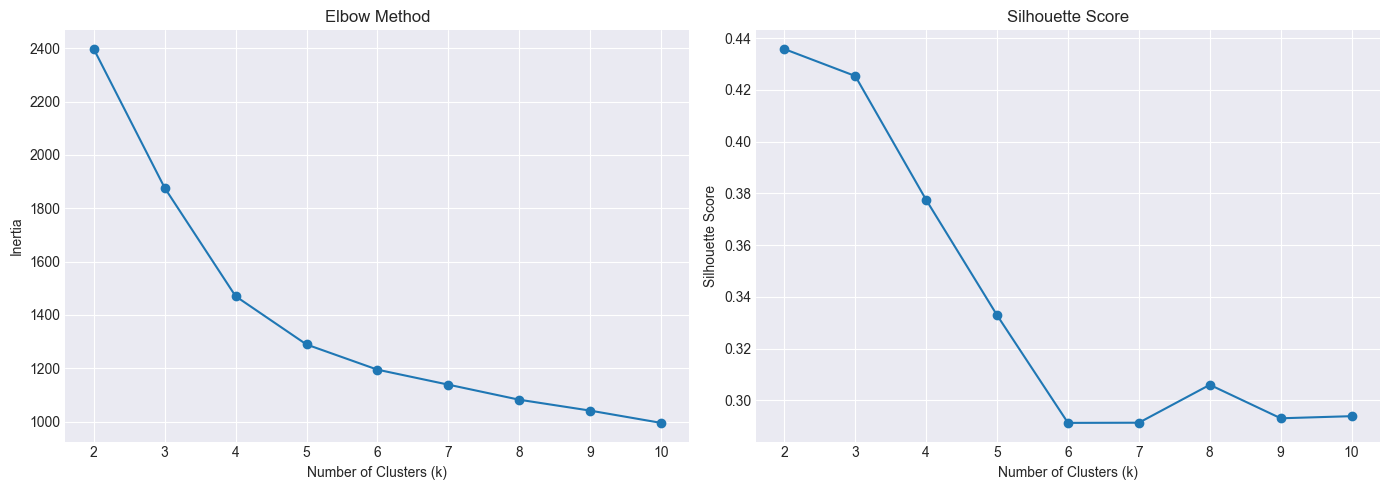

In [45]:
k_values = range(2, 11)

inertia = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Elbow Method
axes[0].plot(k_values, inertia, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

# Silhouette Score
axes[1].plot(k_values, silhouette_scores, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Based on the Elbow Method and Silhouette Analysis, k = 4 was selected as the optimal number of clusters. The elbow plot shows diminishing returns beyond k=4, while the silhouette score indicates that k=4 provides the best clustering solution.

#### **K-Means Clustering**

Now that the optimal number of clusters is determined, we can now start clustering.

In [46]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

scommerce_df["Cluster"] = clusters

#### **Cluster Size**
Cluster sizes were examined to describe the distribution of respondents across the identified clusters.

In [47]:
cluster_sizes = (
    scommerce_df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_sizes

Cluster
0     97
1    258
2     20
3    382
Name: count, dtype: int64

Cluster 3 contained the largest number of respondents (382), followed by Cluster 1 (258), Cluster 0 (97), and Cluster 2 (20).

#### **Cluster Profiling**
Cluster profiles were generated by computing the mean values of the six behavioral constructs together with AUB for each cluster. These mean scores were used to characterize the identified user segments.

<Axes: ylabel='Cluster'>

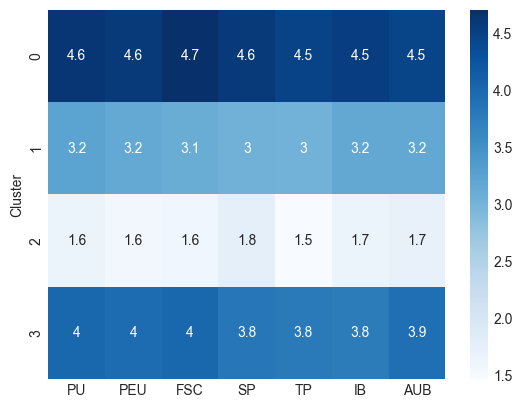

In [48]:
cluster_profile = (
    scommerce_df
    .groupby("Cluster")[features + ["AUB"]]
    .mean()
)

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="Blues"
)

#### **Cluster 0: Highly Engaged Social Commerce Users**

AUB = 4.47, PU = 4.64, PEU = 4.58, FSC = 4.71, SP = 4.58, TP = 4.47, IB = 4.53

Cluster 0 consists of respondents who exhibit consistently high scores across all behavioral and perception constructs, with mean values above 4.4. Respondents in this cluster perceive social commerce platforms as useful and easy to use, are highly familiar with social commerce, trust the platforms, experience a strong sense of social presence, and actively interact with others. Consequently, they also demonstrate a high level of Actual Usage Behavior (AUB = 4.47). These respondents can be characterized as highly engaged and active social commerce users, indicating that positive perceptions across all measured constructs are associated with frequent use of social commerce platforms.

#### **Cluster 1: Moderate or Occasional Users**

AUB = 3.17, PU = 3.25, PEU = 3.16, FSC = 3.10, SP = 3.05, TP = 3.03, IB = 3.17

Cluster 1 represents respondents with generally neutral to moderately positive perceptions of social commerce. Their scores across all constructs are close to 3, suggesting that they neither strongly agree nor disagree with the statements measuring the constructs. This is reflected in their moderate Actual Usage Behavior (AUB = 3.17). These respondents may use social commerce occasionally but are not highly engaged. Improving their perceptions of the platform, particularly in areas such as trust and social interaction, may encourage greater adoption and more frequent usage.

#### **Cluster 2: Low Engagement Users**

AUB = 1.71, PU = 1.65, PEU = 1.57, FSC = 1.58, SP = 1.78, TP = 1.47, IB = 1.66

Cluster 2 contains the smallest number of respondents and exhibits the lowest mean scores across all constructs. Respondents in this cluster generally disagree that social commerce platforms are useful, easy to use, trustworthy, or socially engaging, resulting in the lowest level of Actual Usage Behavior (AUB = 1.71) among all clusters.

#### **Cluster 3: Regular Users with Positive Perceptions**

AUB = 3.92, PU = 4.02, PEU = 3.96, FSC = 4.02, SP = 3.82, TP = 3.79, IB = 3.77

Cluster 3 is the largest cluster in the dataset and represents respondents with generally positive perceptions of social commerce. While their scores are slightly lower than those of Cluster 0, they still report favorable levels of perceived usefulness, ease of use, familiarity, trust, social presence, and interaction behavior, which is reflected in their relatively high Actual Usage Behavior (AUB = 3.92). Compared with Cluster 1, respondents in this cluster consistently exhibit higher scores across all constructs, suggesting stronger confidence and engagement with social commerce rather than the moderate or uncertain perceptions observed in Cluster 1. However, compared to Cluster 0, they appear to be regular users rather than highly engaged users. Since this is the largest cluster, it may represent the typical Generation Z university student who has adopted social commerce and uses it regularly but whose engagement and confidence are not as strong as those observed in Cluster 0.

#### **Table Summary**

Below is the summary of Overall Profile, AUB, and Main Characteristics of the four clusters.

$$
\begin{array}{|l|l|c|l|}
\hline
\textbf{Cluster} & \textbf{Overall Profile} & \textbf{AUB} & \textbf{Main Characteristic} \\
\hline
0 & \text{Highly Engaged Users} & 4.47 & \text{Very high engagement across all constructs} \\
\hline
1 & \text{Moderate/Occasional Users} & 3.17 & \text{Neutral perceptions and moderate usage} \\
\hline
2 & \text{Low Engagement Users} & 1.71 & \text{Low perceptions and minimal usage} \\
\hline
3 & \text{Regular Users} & 3.92 & \text{Positive perceptions and regular usage} \\
\hline
\end{array}
$$

### [2] Statistical Inference

Since AUB was excluded during cluster formation, it was analyzed separately to determine whether actual usage behavior differs significantly across the identified clusters.

To determine whether AUB differs among the identified clusters, the following hypotheses are formulated.


$$
H_0:\ \mu_0 = \mu_1 = \mu_2 = \mu_3,\ \text{where the mean AUB is equal across all clusters.}
$$

$$
H_1:\ \exists\, i \ne j : \mu_i \ne \mu_j,\ \text{where at least one cluster has a different mean AUB.}
$$

#### **Assumption Checking**

Before performing One-Way ANOVA, its assumptions were evaluated. Independent observations and a continuous dependent variable were satisfied; therefore, only normality was assessed using the Shapiro-Wilk test. The hypotheses are defined as follows.

$H_0$: The AUB values within each cluster are normally distributed.

$H_1$: The AUB values within each cluster are not normally distributed.

In [49]:
for cluster in sorted(scommerce_df["Cluster"].unique()):
    stat, p = shapiro(
        scommerce_df.loc[scommerce_df["Cluster"] == cluster, "AUB"]
    )

    print(f"Cluster {cluster}: W={stat:.4f}, p={p:.4f}")

Cluster 0: W=0.8871, p=0.0000
Cluster 1: W=0.8512, p=0.0000
Cluster 2: W=0.8787, p=0.0168
Cluster 3: W=0.8786, p=0.0000


Since all clusters yielded p < .05, the normality assumption was violated. Therefore, the Kruskal–Wallis H test was used instead of One-Way ANOVA, and the hypotheses were reformulated as follows.

### **The hypotheses for the Kruskal–Wallis H test are formulated as follows.**

$$
H_0:\ \text{The distribution of AUB is identical across all clusters.}
$$

$$
H_1:\ \text{At least one cluster has a different distribution of AUB.}
$$

The Kruskal–Wallis H test compares the distributions of groups using ranked observations and does not require the assumption of normality. Therefore, it is an appropriate non-parametric alternative to One-Way ANOVA for comparing AUB across clusters.

The assumptions of independent observations, independent groups, and an ordinal/continuous dependent variable were satisfied because each respondent belonged to only one cluster and AUB was treated as a continuous aggregated Likert-scale score. The test was therefore performed at $\alpha = 0.05$.

In [50]:
# Extract the AUB scores for each cluster.
# Each element in 'groups' contains the AUB values of one cluster.
groups = [
    scommerce_df.loc[scommerce_df["Cluster"] == c, "AUB"]
    for c in sorted(scommerce_df["Cluster"].unique())
]

# Perform the Kruskal–Wallis H test.
# The * operator unpacks the list so that each cluster is passed
# as a separate sample to the function.
H, p = kruskal(*groups)

# Display the test statistic (H) and the corresponding p-value.
# H measures the difference in the average ranks of the groups,
# while the p-value determines whether the observed differences
# are statistically significant.
print(f"H-statistic: {H}")
print(f"p-value: {p}")

H-statistic: 421.3159298947122
p-value: 5.341699041631374e-91


The Kruskal–Wallis H test revealed a statistically significant difference in the distribution of AUB across the four identified clusters (H = 421.32, p < .001). Therefore, the null hypothesis was rejected. Dunn's post hoc test with Bonferroni correction was subsequently performed to identify which cluster pairs differed significantly.

#### **Post Hoc Analysis**

Dunn's post hoc test with Bonferroni correction was performed to identify the significantly different cluster pairs. For each pairwise comparison, the hypotheses are defined as follows.

$H_0$: There is no statistically significant difference in the distribution of AUB between the two clusters being compared.

$H_1$: There is a statistically significant difference in the distribution of AUB between the two clusters being compared.

In [51]:
dunn = sp.posthoc_dunn(
    scommerce_df,
    val_col="AUB",
    group_col="Cluster",
    p_adjust="bonferroni"
)

dunn = pd.DataFrame(dunn)

print(dunn.round(4).to_string())

     0       1       2    3
0  1.0  0.0000  0.0000  0.0
1  0.0  1.0000  0.0022  0.0
2  0.0  0.0022  1.0000  0.0
3  0.0  0.0000  0.0000  1.0


Dunn's post hoc test showed that all pairwise comparisons were statistically significant (*p* < .05). Therefore, the distribution of AUB differed significantly between every pair of identified clusters, indicating that each cluster represents a distinct pattern of Actual Usage Behavior.

### [3] Insights and Conclusions

#### **Insights**

After performing a clustering analysis, four distinct segments of Generation Z university students were identified based on their perceptions of social commerce: Highly Engaged Users, Regular Users with Positive Perceptions, Moderate or Occasional Users, and Low Engagement Users. The Elbow Method and Silhouette Analysis identified four clusters as the most suitable segmentation, indicating meaningful differences among respondents.

The cluster profiles reveal a clear relationship between users' perceptions of social commerce and their actual usage behavior. Respondents who reported higher levels of Perceived Usefulness (PU), Perceived Ease of Use (PEU), Familiarity with Social Commerce (FSC), Social Presence (SP), Trust in Platform (TP), and Interaction Behavior (IB) also exhibited higher Actual Usage Behavior (AUB). Conversely, respondents with consistently low perception scores demonstrated the lowest platform usage.

The largest cluster consisted of Regular Users with Positive Perceptions, suggesting that most respondents view social commerce favorably and engage with these platforms regularly, though not at the highest level. In contrast, Highly Engaged Users represented a smaller but strongly committed group with consistently high ratings across all behavioral constructs. Low Engagement Users formed the smallest cluster, indicating that only a limited portion of respondents maintain negative perceptions and low platform usage.

Statistical inference further validated the clustering results. The Shapiro-Wilk test assessed normality, and since the assumption was violated, the Kruskal-Wallis H test was used instead of One-Way ANOVA. The test found a statistically significant difference in Actual Usage Behavior across the four clusters (H = 421.32, p < .001). Dunn's post hoc analysis showed that every pair of clusters differed significantly, confirming that each segment represents a distinct level of social commerce engagement.

Overall, the findings suggest that positive perceptions of usefulness, ease of use, trust, familiarity, social presence, and interaction behavior are consistently associated with greater adoption and continued use of social commerce platforms among Generation Z university students.

#### **Conclusions**

This study successfully addressed the research question by identifying distinct behavioral segments among Generation Z university students through K-Means clustering. Four meaningful user profiles were discovered, each exhibiting different levels of perception toward social commerce and actual usage behavior.

The results demonstrate that students with more positive perceptions consistently exhibit higher platform usage, while less favorable perceptions are associated with lower engagement. Statistical testing confirmed that Actual Usage Behavior differs significantly across all clusters, reinforcing the validity and practical relevance of the segmentation.

These findings indicate that Generation Z users are not homogeneous. They differ in their attitudes, trust, familiarity, and engagement with social commerce platforms. Consequently, businesses and platform developers should adopt segment-specific strategies. Enhancing usability, trust, interactive features, and user familiarity may help encourage less engaged users to become more active while maintaining existing high-usage users.

Although the study provides meaningful insights into social commerce behavior among Generation Z university students, its findings are limited to the surveyed population and variables included in the dataset. The original dataset was collected through voluntary online and offline recruitment, with online recruitment relying on Facebook and Zalo. This may introduce self-selection bias and overrepresent students who are more active on social media or familiar with social commerce. Consequently, the identified segments may not fully represent the broader Generation Z student population. Future studies may employ more representative sampling, expand the respondent population, incorporate additional factors, and explore alternative clustering techniques to further validate these segments.